# PH05 — Transfer ResNet18 sang Derm7pt

Notebook này tiếp tục từ PH04.

Mục tiêu:
- Load checkpoint `resnet18_best.pth` đã train trên HAM10000.
- Thay head phân loại: 7 lớp nguồn → 5 lớp target Derm7pt.
- Fine-tune 2 giai đoạn: train head trước (HEAD_EPOCHS), rồi unfreeze toàn bộ backbone.
- Ghi CSV log và lưu best checkpoint theo `val_acc`.

## 1. Import thư viện

In [1]:
import csv
import time
from pathlib import Path

import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import models

import pandas as pd
import matplotlib.pyplot as plt

## 2. Thiết lập đường dẫn project

In [2]:
PROJECT_ROOT = Path.cwd().parent
SRC_DIR      = PROJECT_ROOT / 'src'

import sys
sys.path.insert(0, str(SRC_DIR))

from transforms import get_resnet_transforms

SPLIT_DIR = PROJECT_ROOT / 'data' / 'splits'
CKPT_DIR  = PROJECT_ROOT / 'checkpoints'
LOG_DIR   = PROJECT_ROOT / 'logs'
RES_DIR   = PROJECT_ROOT / 'results'

CKPT_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR.mkdir(parents=True, exist_ok=True)

SOURCE_CKPT = CKPT_DIR / 'resnet18_best.pth'
TARGET_CKPT = CKPT_DIR / 'resnet18_derm7pt_best.pth'
LOG_PATH    = LOG_DIR  / 'resnet18_derm7pt_log.csv'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Project root : {PROJECT_ROOT}')
print(f'Device       : {DEVICE}')
print(f'Source ckpt  : {SOURCE_CKPT} (exists={SOURCE_CKPT.exists()})')
if DEVICE.type == 'cuda':
    print(f'GPU          : {torch.cuda.get_device_name(0)}')

Project root : c:\Users\ADMIN\python\Phan_loai_ton_thuong_da_bang_ResNet_va_ViT
Device       : cpu
Source ckpt  : c:\Users\ADMIN\python\Phan_loai_ton_thuong_da_bang_ResNet_va_ViT\checkpoints\resnet18_best.pth (exists=True)


## 3. Cấu hình target dataset

In [3]:
# Nhãn Derm7pt (5 lớp) theo thứ tự đã định nghĩa ở notebook 02 & 03
DERM_LABELS      = ['bcc', 'mel', 'misc', 'nevus', 'sk']
DERM_TO_INDEX    = {label: idx for idx, label in enumerate(DERM_LABELS)}
NUM_CLASSES_SOURCE = 7  # HAM10000 — phải khớp kiến trúc checkpoint
NUM_CLASSES_TARGET = 5  # Derm7pt

BATCH_SIZE   = 32
NUM_EPOCHS   = 10
HEAD_EPOCHS  = 3   # Số epoch chỉ train head, sau đó unfreeze backbone
LR_HEAD      = 1e-4
LR_BACKBONE  = 1e-5
WEIGHT_DECAY = 1e-4
NUM_WORKERS  = 0

print('DERM_LABELS        =', DERM_LABELS)
print(f'NUM_CLASSES_SOURCE = {NUM_CLASSES_SOURCE}')
print(f'NUM_CLASSES_TARGET = {NUM_CLASSES_TARGET}')
print(f'HEAD_EPOCHS / NUM_EPOCHS = {HEAD_EPOCHS} / {NUM_EPOCHS}')

DERM_LABELS        = ['bcc', 'mel', 'misc', 'nevus', 'sk']
NUM_CLASSES_SOURCE = 7
NUM_CLASSES_TARGET = 5
HEAD_EPOCHS / NUM_EPOCHS = 3 / 10


## 4. DermDataset — dataset cho Derm7pt

CSV từ notebook 03 (`derm7pt_train/val.csv`) có cột `label` (string: 'nevus', 'mel', ...)
và `img_path`. Lớp này map trực tiếp sang integer, không dùng qua `SkinDataset`
vì `SkinDataset` validate theo `LABEL_MAP` cứng của HAM10000.

In [4]:
class DermDataset(Dataset):
    """
    Dataset cho Derm7pt.
    CSV cần có cột 'img_path' và 'label' (string, ví dụ 'nevus', 'mel').
    """
    def __init__(self, csv_path, label_map, transform=None):
        self.df        = pd.read_csv(csv_path)
        self.transform = transform

        if 'label' not in self.df.columns or 'img_path' not in self.df.columns:
            raise ValueError("CSV cần có cột 'label' và 'img_path'")

        self.df['int_label'] = self.df['label'].map(label_map)
        unmapped = self.df['int_label'].isna()
        if unmapped.any():
            bad = self.df.loc[unmapped, 'label'].unique()
            raise ValueError(f"Nhãn chưa có trong label_map: {bad}")
        self.df['int_label'] = self.df['int_label'].astype(int)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['img_path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, row['int_label']

## 5. Tạo dataset và dataloader

In [5]:
train_ds = DermDataset(
    SPLIT_DIR / 'derm7pt_train.csv',
    label_map=DERM_TO_INDEX,
    transform=get_resnet_transforms('train'),
)
val_ds = DermDataset(
    SPLIT_DIR / 'derm7pt_val.csv',
    label_map=DERM_TO_INDEX,
    transform=get_resnet_transforms('val'),
)
test_ds = DermDataset(
    SPLIT_DIR / 'derm7pt_test.csv',
    label_map=DERM_TO_INDEX,
    transform=get_resnet_transforms('val'),  # không augment lúc test
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

print(f'Train : {len(train_ds):,}')
print(f'Val   : {len(val_ds):,}')
print(f'Test  : {len(test_ds):,}')
print('\nPhân phối nhãn (train):')
print(train_ds.df['label'].value_counts().reindex(DERM_LABELS))

Train : 413
Val   : 203
Test  : 395

Phân phối nhãn (train):
label
bcc       19
mel       90
misc      32
nevus    256
sk        16
Name: count, dtype: int64


## 6. Class weights cho Derm7pt

In [6]:
def compute_class_weights(dataset):
    counts  = dataset.df['label'].value_counts().reindex(DERM_LABELS)
    weights = 1.0 / counts.values.astype(float)
    weights = weights / weights.sum() * NUM_CLASSES_TARGET
    return torch.tensor(weights, dtype=torch.float32)

class_weights = compute_class_weights(train_ds).to(DEVICE)
for label, w in zip(DERM_LABELS, class_weights.cpu().numpy()):
    print(f'  {label:<8} {w:.4f}')

  bcc      1.6305
  mel      0.3442
  misc     0.9681
  nevus    0.1210
  sk       1.9362


## 7. Build model — load checkpoint HAM10000, thay head

1. Dựng lại kiến trúc source (7 lớp) để `load_state_dict` khớp.
2. Load weights từ `resnet18_best.pth`.
3. Thay `model.fc` thành head 5 lớp Derm7pt (weights mới, random init).
4. Freeze toàn bộ backbone — chỉ train head trong `HEAD_EPOCHS` đầu.

In [7]:
# Bước 1: dựng kiến trúc source để load state_dict không bị mismatch
model       = models.resnet18(weights=None)
in_features = model.fc.in_features  # 512 cho ResNet18

model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, NUM_CLASSES_SOURCE),
)

# Bước 2: load checkpoint
ckpt = torch.load(SOURCE_CKPT, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt['model_state'])
print(f"Loaded checkpoint  : epoch={ckpt['epoch']}, val_acc={ckpt['val_acc']:.4f}")

# Bước 3: thay head 7 → 5 lớp (weights được random init)
model.fc = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, NUM_CLASSES_TARGET),
)

# Bước 4: freeze backbone, chỉ để head có gradient
for name, param in model.named_parameters():
    if 'fc' not in name:
        param.requires_grad = False

model = model.to(DEVICE)

print(f"Head mới           : {model.fc}")
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params   : {trainable:,}  (backbone frozen)")

Loaded checkpoint  : epoch=10, val_acc=0.6973
Head mới           : Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=512, out_features=5, bias=True)
)
Trainable params   : 2,565  (backbone frozen)


## 8. Hàm train_one_epoch và validate

In [8]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)


def validate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0.0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs    = model(images)
            loss       = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
    n = len(loader.dataset)
    return total_loss / n, correct / n

## 9. Fine-tune trên Derm7pt và lưu best model

- **Phase 1** (epoch 1 → HEAD_EPOCHS): chỉ train head, backbone frozen.
- **Phase 2** (epoch HEAD_EPOCHS+1 → NUM_EPOCHS): unfreeze toàn bộ, backbone dùng LR nhỏ hơn.

In [9]:
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.fc.parameters(), lr=LR_HEAD, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

with open(LOG_PATH, 'w', newline='') as f:
    csv.writer(f).writerow(['epoch', 'train_loss', 'val_loss', 'val_acc', 'lr'])

best_val_acc  = 0.0
unfreeze_done = False

for epoch in range(1, NUM_EPOCHS + 1):

    # ── Phase 2: unfreeze backbone khi vượt qua HEAD_EPOCHS ───────────
    if epoch == HEAD_EPOCHS + 1 and not unfreeze_done:
        print('\n[Unfreeze] Mở backbone — fine-tune toàn bộ...')
        for p in model.parameters():
            p.requires_grad = True
        optimizer = torch.optim.Adam([
            {'params': model.fc.parameters(),
             'lr': LR_HEAD},
            {'params': [p for n, p in model.named_parameters() if 'fc' not in n],
             'lr': LR_BACKBONE},
        ], weight_decay=WEIGHT_DECAY)
        scheduler     = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', patience=3, factor=0.5
        )
        unfreeze_done = True

    t0         = time.time()
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = validate(model, val_loader, criterion)
    scheduler.step(val_loss)

    print(
        f'Epoch [{epoch:02d}/{NUM_EPOCHS}]  '
        f'train_loss={train_loss:.4f}  '
        f'val_loss={val_loss:.4f}  '
        f'val_acc={val_acc:.4f}  '
        f'({time.time() - t0:.1f}s)'
    )

    with open(LOG_PATH, 'a', newline='') as f:
        csv.writer(f).writerow([
            epoch,
            f'{train_loss:.6f}',
            f'{val_loss:.6f}',
            f'{val_acc:.6f}',
            f'{optimizer.param_groups[0]["lr"]:.2e}',
        ])

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch'          : epoch,
            'model_state'    : model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'val_acc'        : val_acc,
            'val_loss'       : val_loss,
            'class_names'    : DERM_LABELS,
        }, TARGET_CKPT)
        print(f'  ✅ Saved best  val_acc={val_acc:.4f}')

print(f'\nDone. Best val_acc = {best_val_acc:.4f}')

Epoch [01/10]  train_loss=1.7240  val_loss=1.6222  val_acc=0.2167  (18.7s)
  ✅ Saved best  val_acc=0.2167
Epoch [02/10]  train_loss=1.7170  val_loss=1.5827  val_acc=0.2611  (13.4s)
  ✅ Saved best  val_acc=0.2611
Epoch [03/10]  train_loss=1.7333  val_loss=1.5485  val_acc=0.2906  (14.0s)
  ✅ Saved best  val_acc=0.2906

[Unfreeze] Mở backbone — fine-tune toàn bộ...
Epoch [04/10]  train_loss=1.6298  val_loss=1.4533  val_acc=0.3744  (26.5s)
  ✅ Saved best  val_acc=0.3744
Epoch [05/10]  train_loss=1.5291  val_loss=1.3804  val_acc=0.4187  (26.1s)
  ✅ Saved best  val_acc=0.4187
Epoch [06/10]  train_loss=1.4329  val_loss=1.3168  val_acc=0.5074  (26.2s)
  ✅ Saved best  val_acc=0.5074
Epoch [07/10]  train_loss=1.2898  val_loss=1.2705  val_acc=0.5468  (25.4s)
  ✅ Saved best  val_acc=0.5468
Epoch [08/10]  train_loss=1.2593  val_loss=1.2284  val_acc=0.5862  (26.2s)
  ✅ Saved best  val_acc=0.5862
Epoch [09/10]  train_loss=1.1632  val_loss=1.1998  val_acc=0.5764  (26.2s)
Epoch [10/10]  train_loss=1.13

## 10. Kết quả — log và biểu đồ training

In [10]:
log_df = pd.read_csv(LOG_PATH)
print(log_df.to_string(index=False))

 epoch  train_loss  val_loss  val_acc     lr
     1    1.724024  1.622195 0.216749 0.0001
     2    1.717048  1.582657 0.261084 0.0001
     3    1.733325  1.548539 0.290640 0.0001
     4    1.629805  1.453266 0.374384 0.0001
     5    1.529054  1.380361 0.418719 0.0001
     6    1.432877  1.316815 0.507389 0.0001
     7    1.289766  1.270520 0.546798 0.0001
     8    1.259309  1.228422 0.586207 0.0001
     9    1.163186  1.199771 0.576355 0.0001
    10    1.135515  1.174292 0.596059 0.0001


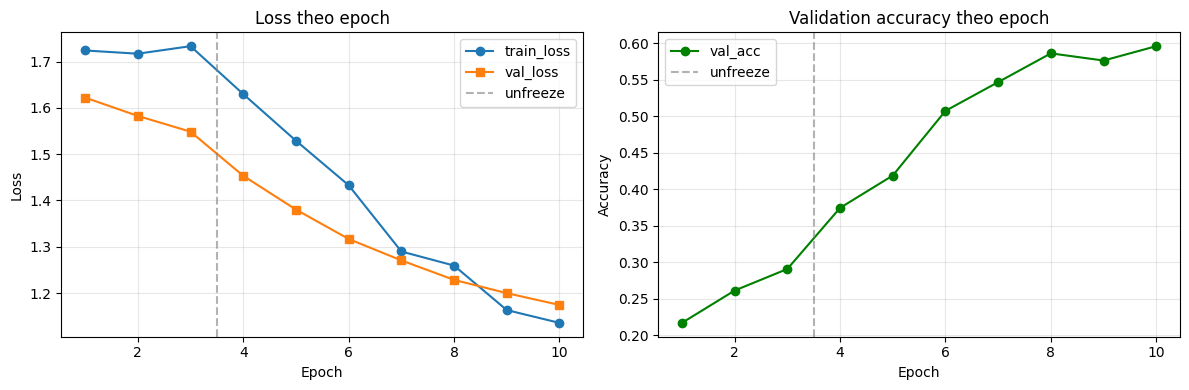

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(log_df['epoch'], log_df['train_loss'], marker='o', label='train_loss')
axes[0].plot(log_df['epoch'], log_df['val_loss'],   marker='s', label='val_loss')
axes[0].axvline(HEAD_EPOCHS + 0.5, color='gray', linestyle='--', alpha=0.6, label='unfreeze')
axes[0].set_title('Loss theo epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(log_df['epoch'], log_df['val_acc'], marker='o', color='green', label='val_acc')
axes[1].axvline(HEAD_EPOCHS + 0.5, color='gray', linestyle='--', alpha=0.6, label='unfreeze')
axes[1].set_title('Validation accuracy theo epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(RES_DIR / 'resnet18_derm7pt_training_curves.png', dpi=120)
plt.show()

## 11. Đánh giá trên test set

Load best checkpoint, chạy trên `test_loader`, báo cáo accuracy và confusion matrix.

In [12]:
# Load best checkpoint
best_ckpt = torch.load(TARGET_CKPT, map_location=DEVICE, weights_only=False)
model.load_state_dict(best_ckpt['model_state'])
print(f"Best checkpoint   : epoch={best_ckpt['epoch']}, val_acc={best_ckpt['val_acc']:.4f}")

# Đánh giá trên test set
test_loss, test_acc = validate(model, test_loader, criterion)
print(f"Test loss         : {test_loss:.4f}")
print(f"Test accuracy     : {test_acc:.4f}")

Best checkpoint   : epoch=10, val_acc=0.5961
Test loss         : 1.1658
Test accuracy     : 0.5975


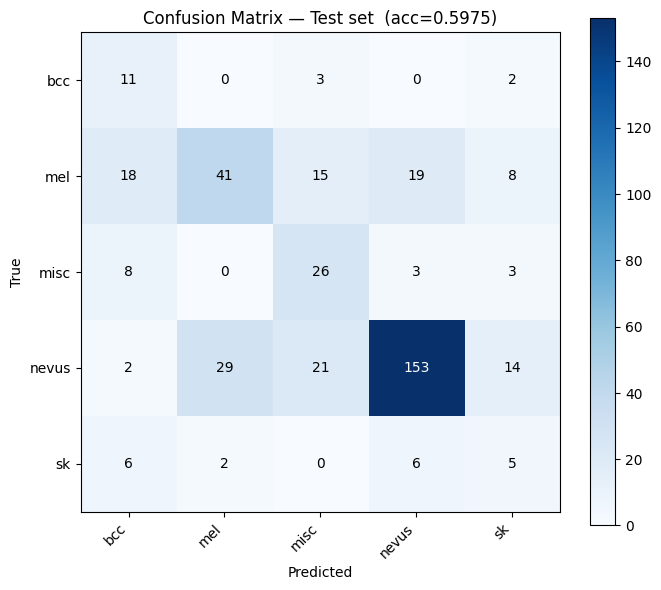


Classification report:
              precision    recall  f1-score   support

         bcc       0.24      0.69      0.36        16
         mel       0.57      0.41      0.47       101
        misc       0.40      0.65      0.50        40
       nevus       0.85      0.70      0.77       219
          sk       0.16      0.26      0.20        19

    accuracy                           0.60       395
   macro avg       0.44      0.54      0.46       395
weighted avg       0.67      0.60      0.62       395



In [13]:
# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        preds = model(images.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)
ax.set_xticks(range(NUM_CLASSES_TARGET))
ax.set_yticks(range(NUM_CLASSES_TARGET))
ax.set_xticklabels(DERM_LABELS, rotation=45, ha='right')
ax.set_yticklabels(DERM_LABELS)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — Test set  (acc={test_acc:.4f})')

for i in range(NUM_CLASSES_TARGET):
    for j in range(NUM_CLASSES_TARGET):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')

plt.tight_layout()
fig.savefig(RES_DIR / 'resnet18_derm7pt_confusion_matrix.png', dpi=120)
plt.show()

print('\nClassification report:')
print(classification_report(all_labels, all_preds, target_names=DERM_LABELS))